<a href="https://colab.research.google.com/github/andresjg27/BNS-Merger-Rate-Population-Code/blob/main/Andres_Merger_Rate_Code_Clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing Stuff



In [1]:
#importing files, some may not be used
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import seaborn as sns
from astropy.cosmology import WMAP9 as cosmo
import astropy.units as u
from astropy.cosmology import Planck13, z_at_value
import scipy as sp

import pycbc
from pycbc.conversions import mchirp_from_mass1_mass2
from pycbc import types, fft, waveform
from pycbc.waveform import get_fd_waveform
from pycbc import psd
from pycbc.filter.matchedfilter import sigmasq

!pip install pycbc lalsuite ligo-common seaborn
! git clone https://gitlab.com/jocelyn.read/cosmic-explorer-data-references.git
# Only needs to be done once
! ls cosmic-explorer-data-references
#testing to see if data can be retrieved

/opt/miniconda3/envs/gwenv/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal
PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1
/opt/miniconda3/envs/gwenv/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30

fatal: destination path 'cosmic-explorer-data-references' already exists and is not an empty directory.
DTD_ndot        README.md       common-3g-data  curves_May_2019 postmerger-refs


##Observatory Noise Curves


advirgo.txt       aplus_sqzonly.txt kagra_sqz.txt     o3_l1.txt
advirgo_sqz.txt   ce.txt            kagra_wb.txt      o3_v1.txt
advirgo_wb.txt    ce_wb.txt         o1.txt            s6.txt
aligo.txt         er8.txt           o2.txt            voyager.txt
aligo_design.txt  et_d.txt          o2_crossspec.txt
aplus.txt         kagra.txt         o3_h1.txt
0 ALIGO cosmic-explorer-data-references/curves_May_2019/aligo.txt
1 APLUS cosmic-explorer-data-references/curves_May_2019/aplus.txt
2 Voyager cosmic-explorer-data-references/curves_May_2019/voyager.txt
3 CE cosmic-explorer-data-references/curves_May_2019/ce_wb.txt


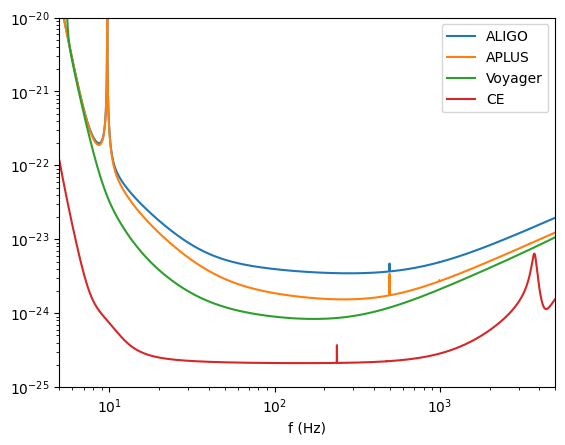

In [ ]:
! ls cosmic-explorer-data-references/curves_May_2019
# https://dcc.ligo.org/LIGO-T1500293/public

DetectorNames = ["ALIGO","APLUS","Voyager","CE"]
DetectorFiles = ["aligo.txt","aplus.txt","voyager.txt","ce_wb.txt"]

DetectorASDDataList = []
for i, detname in enumerate(DetectorNames):
  print(i,detname,"cosmic-explorer-data-references/curves_May_2019/"+DetectorFiles[i])
  psddata = np.genfromtxt("cosmic-explorer-data-references/curves_May_2019/"+DetectorFiles[i])
  DetectorASDDataList.append(psddata)
DetectorASDData = dict(zip(DetectorNames, DetectorASDDataList))

for detname in DetectorNames:
  plt.loglog(np.append(DetectorASDData[detname][:,0],16*2048),
    np.append(DetectorASDData[detname][:,1],1.e-22),label=detname)
  # WILL NEED HIGH FREQUENCY FOR NS MERGER CALCULATIONS 
  # Add a high-frequency point to everything that behaves reasonably [HACK]
  # CE - skyloc dependent noise curve, may need to implement following https://arxiv.org/abs/1708.06843
plt.legend()
plt.ylim(1e-25,1e-20)
plt.xlim(5,5000)
plt.xlabel("f (Hz)")

#VOyager is basically Asharp - telescope between now and CE ~3 orders of magnitude improvement - less rane more precise
#Could also see what % of grb are pointed at us

DetectorPSDDataList=[]
  # Add a high-frequency point to everything that behaves reasonably [HACK]
for detname in DetectorNames:
  PSD = np.array((
      np.append(DetectorASDData[detname][:,0],16*2048),
    np.power(np.append(DetectorASDData[detname][:,1],1.e-22),2))).T
  DetectorPSDDataList.append(PSD)
DetectorPSDData = dict(zip(DetectorNames, DetectorPSDDataList))

##Mass Models


Text(0.5, 1.0, 'NS Mass Distributions')

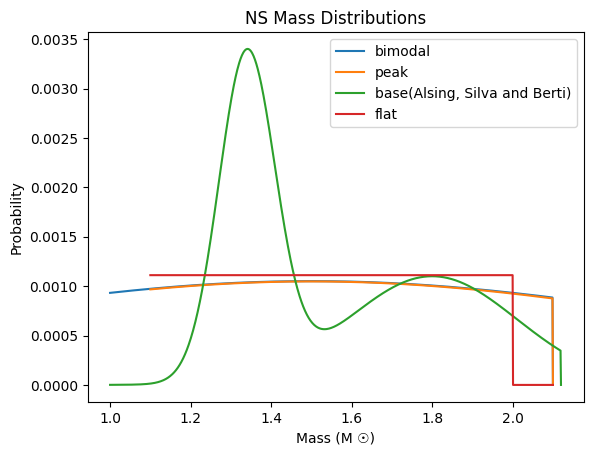

In [3]:
#I'm going to create a numpy array with the values and uncertainties from Table 1
#it will be arranged as follows (mmin, mmax, mu1, sig1, mu2, sig2, w?)
flat_params = np.array(((1.1,0.2,-0.1),(2.0,0.4,-0.3)))
peak_params = np.array(((1.1,0.2,-0.1),(2.1,0.7,-0.3),(1.5,0.5,-0.3),(1.0,0.9,-0.7)))
bimodal_params = np.array(((1.0,0,0),(2.1,0.7,-0.3),(1.3,0.5,-0.3),(1.0,0.9,-0.8),(1.7,0.6,-0.4),(1.0,0.9,-0.9),(0.5,0.5,-0.4)))

qflat_params = np.array(((1.1,0.1,-0.2),(2.0,0.3,-0.3)))
qpeak_params = np.array(((1.1,0.2,-0.1),(2.1,0.7,-0.2),(1.5,0.5,-0.3),(1.0,0.9,-0.7)))
qbimodal_params = np.array(((1.0,0,0),(2.1,0.7,-0.3),(1.3,0.5,-0.3),(0.9,1.0,-0.8),(1.7,0.5,-0.4),(1.0,0.9,-0.9),(0.5,0.5,-0.4)))

#defining my gaussian curve
def gaussian(x, mu, sig):
    return 1./(np.sqrt(2.*np.pi)*sig)*np.exp(-np.power((x - mu)/sig, 2.)/2)
bimodal_mmin = bimodal_params[0,0]
bimodal_mmax = bimodal_params[1,0]
peak_mmin = peak_params[0,0]
peak_mmax = peak_params[1,0]
flat_mmin = flat_params[0,0]
flat_mmax = flat_params[1,0]
def bimodal_mass(m):
  if m < bimodal_mmax:
    return gaussian(m, bimodal_params[2,0], bimodal_params[3,0]) + gaussian(m, bimodal_params[4,0], bimodal_params[5,0])
  return 0
def peak_mass(m):
  if m < peak_mmax:
    return gaussian(m,peak_params[2,0], peak_params[3,0])
  return 0
def flat_mass(m):
  if m < flat_mmax:
    return 1/(flat_mmax-flat_mmin)
  return 0

#gonna plot the data now hope it works
#create my linspace so my gaussian has something to plot to
bimodal_NSmasses = np.linspace(bimodal_mmin,bimodal_mmax, 1000)
bimodal_mass_dist = [bimodal_mass(m) for m in bimodal_NSmasses]
#below to normalize
bimodal_mass_dist = bimodal_mass_dist/np.sum(bimodal_mass_dist)

peak_NSmasses = np.linspace(peak_params[0,0], peak_params[1,0], 1000 )
peak_mass_dist = [peak_mass(m) for m in peak_NSmasses]
peak_mass_dist = peak_mass_dist/np.sum(peak_mass_dist)

flat_NSmasses = np.linspace(flat_params[0,0], peak_params[1,0],1000)
flat_mass_dist = [flat_mass(m) for m in flat_NSmasses]
flat_mass_dist = flat_mass_dist/np.sum(flat_mass_dist)



#Dr. Read Code
twogaussian_mmax_params = np.array((
(1.34,0.03, -0.02 ),
(1.80,0.15, -0.18 ),
(0.07,0.02, -0.02 ),
(0.21,0.18,-0.14 ),
(0.65,0.08,-0.15 ),
(2.12,0.09,-0.12))
)

def gaussian(x, mu, sig):
    return 1./(np.sqrt(2.*np.pi)*sig)*np.exp(-np.power((x - mu)/sig, 2.)/2)
mmaxNS = twogaussian_mmax_params[-1,0]
mminNS = 1.0
def massmodel(m):
    if m < mmaxNS:
      return gaussian(m, twogaussian_mmax_params[0,0],twogaussian_mmax_params[2,0]) + gaussian(m, twogaussian_mmax_params[1,0],twogaussian_mmax_params[3,0])
    return 0
baseNSmasses = np.linspace(mminNS,mmaxNS,1000)
NSmassdist = [massmodel(m) for m in baseNSmasses]
NSmassdist = NSmassdist/np.sum(NSmassdist)

#now this is a plot

plt.plot(bimodal_NSmasses,bimodal_mass_dist,label='bimodal')
plt.plot(peak_NSmasses, peak_mass_dist,label='peak')
plt.plot(baseNSmasses, NSmassdist, label='base(Alsing, Silva and Berti)' )
plt.plot(flat_NSmasses,flat_mass_dist, label='flat')
plt.xlabel('Mass (M ☉)')
plt.ylabel('Probability')
plt.legend()
plt.title('NS Mass Distributions')

##SFR

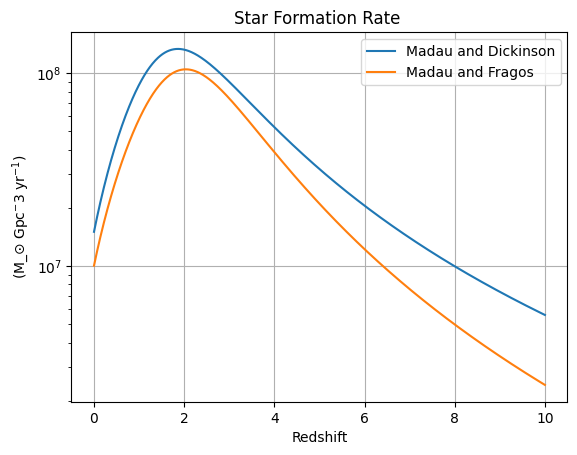

In [4]:
redshift_basevals = np.linspace(0.001,10,1000)
#sfr from madau and dickinson
def sfr(zb):
  if zb > 0:
    return (0.015 * ((1+zb) ** 2.7)/(1+(((1+zb)/2.9) ** 5.6))) * 10**9

sfr_history = [sfr(z) for z in redshift_basevals]

#below is from Madau and Fragos 2017 https://iopscience.iop.org/article/10.3847/1538-4357/aa6af9 (Zevin uses this)

def sfr_mf(z):
      return (0.01 * ((1+z) ** 2.6)/(1+(((1+z)/3.2) ** 6.2))) * 10**9
sfr_mf_bins = [sfr_mf(z) for z in redshift_basevals]


plt.plot(redshift_basevals, sfr_history, label='Madau and Dickinson')
plt.plot(redshift_basevals, sfr_mf_bins, label = 'Madau and Fragos' )
plt.xlabel('Redshift')
plt.ylabel('(M_${\odot}$ Gpc$^{-}3$ yr$^{-1}$)')
#plt.yscale('log')
plt.legend()
plt.title('Star Formation Rate ')
plt.grid()
plt.yscale('log')

#plt.xlim(2,10)
#plt.ylim(10e-4,0)

##Delay Time Distribution

9.210340371976205
7.244227515603349


/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/3214583919.py:50: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  norm_20 = 1/(sp.integrate.quad(dtd_20, 0.01*10**9, 100*10**9)[0])


Text(0.5, 1.0, 'Delay Time Distributions with Different Slopes and tmin = 10Myr, tmin = 100Myr')

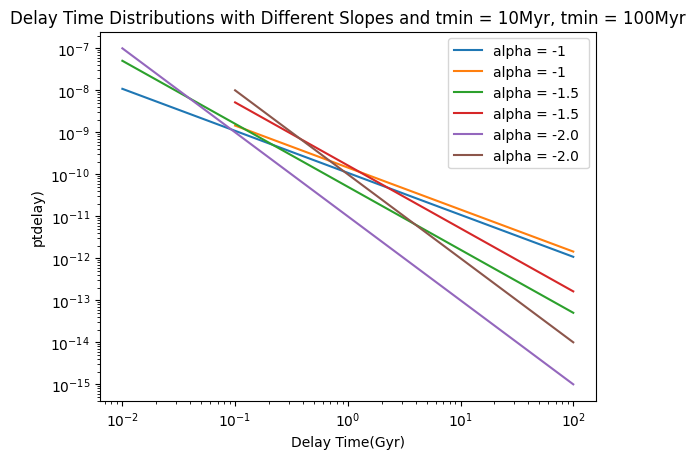

In [5]:

N = ((np.log10(100/0.01))**-1) #normalization constant data #does NOT work but Zevin uses it (allegedely)
#Delay times for tmin=10Myr
delaytimesyr = np.linspace(0.01*10**9,100*10**9, 1000000)
delaytimesGPC = np.linspace(0.010,100, 1000000)

#Delay times for tmin = 100 Myr
delaytimesyr2 = np.linspace(0.1*10**9,100*10**9, 1000000)
delaytimesGPC2 = np.linspace(0.1,100, 1000000)
#SLOPE -1
def dtd(t,tmin,tmax):
  if tmin <= t <= tmax:
    return ((((t) ** -1)))

dtdstandard = [dtd(t, 0.01*10**9, 100*10**9)* 1/9.210340371976203 for t in delaytimesyr]
dtdstandard2 = [dtd(t, 0.1*10**9, 100*10**9) for t in delaytimesyr]

def dtd_equation(x):
  return 1/x

Norm = sp.integrate.quad(dtd_equation, 0.01*10**9, 100*10**9)
print(Norm[0])

Norm2 = sp.integrate.quad(dtd_equation, 0.1*10**9, 100*10**9)

dtdstandard = [dtd(t, 0.01*10**9, 100*10**9)* 1/Norm[0] for t in delaytimesyr]
dtdstandard2 = [dtd(t, 0.1*10**9, 100*10**9)* 1/Norm2[0]for t in delaytimesyr2]

#DTD normalization for my data
Norm_fiducial = sp.integrate.quad(dtd_equation, 0.01*10**9, 14*10**9)
print(Norm_fiducial[0])

dtd_norm_fiducial = 1/7.244227515603351

#SLOPE -1.5

def dtd_15(t):
  return t ** (-1.5)

norm_15 = 1/(sp.integrate.quad(dtd_15, 0.01*10**9, 100*10**9)[0])
norm_152 = 1/(sp.integrate.quad(dtd_15, 0.1*10**9, 100*10**9)[0])

delaytimes_15 = [dtd_15(t)*norm_15 for t in delaytimesyr]
delaytimes_152 = [dtd_15(t)*norm_152 for t in delaytimesyr2]

#SLOPE -2

def dtd_20(t):
  return t ** (-2)

norm_20 = 1/(sp.integrate.quad(dtd_20, 0.01*10**9, 100*10**9)[0])
norm_202 = 1/(sp.integrate.quad(dtd_20, 0.1*10**9, 100*10**9)[0])

delaytimes_20 = [dtd_20(t)*norm_20 for t in delaytimesyr]
delaytimes_202 = [dtd_20(t)*norm_202 for t in delaytimesyr2]

plt.loglog(delaytimesGPC, dtdstandard, label = 'alpha = -1')
plt.loglog(delaytimesGPC2, dtdstandard2, label = 'alpha = -1')
plt.loglog(delaytimesGPC, delaytimes_15, label = 'alpha = -1.5 ')
plt.loglog(delaytimesGPC2, delaytimes_152, label = 'alpha = -1.5 ')
plt.loglog(delaytimesGPC, delaytimes_20, label = 'alpha = -2.0 ')
plt.loglog(delaytimesGPC2, delaytimes_202, label = 'alpha = -2.0 ')

plt.ylabel('ptdelay)')
plt.xlabel('Delay Time(Gyr)')
plt.legend()
plt.title('Delay Time Distributions with Different Slopes and tmin = 10Myr, tmin = 100Myr')
#plt.xlim(2,10)
#plt.ylim(10e-13,10e-8)
#(We don't know the sfr well enough to claim certain things about measurement we just wanna be careful to say how changes in the dtd affect r process stuff)

In [6]:
print(norm_15)

1597.1099293778957


##Merger Rate Code

In [7]:
#Unit conversions
sfr_to_Gpc = 10**9
H0 = cosmo.H0.to(1/u.Gyr).value

print('conversion from H0 to H0 in Gyr is ', cosmo.H0.value/cosmo.H0.to(1/u.Gyr).value)
print(cosmo.H0.value/977.79)
cosmo_H0to_Gyr = 977.79

conversion from H0 to H0 in Gyr is  977.7922216807892
0.07089456836335


In [8]:
def mergerrate(zm, slope, tmin, tmax): #zm is the z at merger

  def sfr_in_use(z):
      return (0.01 * ((1+z) ** 2.6)/(1+(((1+z)/3.2) ** 6.2))) # Madau and fragos

  def plbmdt(z, zm, slope, tmin, tmax):
    a = ((((cosmo.lookback_time(zm) - cosmo.lookback_time(z))/u.Gyr - tmin))** -slope) # Safarzadeh has a similar subtraction in their dtd parameterization but they use 0.01, so I assume Zevin does the same thing implicitly

    if  cosmo.lookback_time(zm)/u.Gyr - tmax <=  ((cosmo.lookback_time(zm) - cosmo.lookback_time(z))/u.Gyr) <= cosmo.lookback_time(zm)/u.Gyr - tmin:
     return a
    else:
      return 0

  def dtdz(z):
    return ((cosmo.H0.value * (((cosmo.Om0 * (((1+z) ** 3))) + cosmo.Ode0 * (z))**0.5) * (1+z)) ** -1)

  def ndotintegrand(z):
    return ( plbmdt(z, zm, 1, tmin, tmax) * 10**-5 * sfr_in_use(z) * dtdz(z))

  def dtd(t, slope):
      return t**slope

  def normalization(slope, tmin, tmax):
      return 1/(sp.integrate.quad(dtd, tmin*10**9, tmax*10**9, args = (slope))[0])

  I = sp.integrate.quad(ndotintegrand, np.inf, zm)[0]
  return (I * normalization(slope, tmin, tmax) * cosmo_H0to_Gyr * sfr_to_Gpc)
  

In [9]:
ndotvalues = [mergerrate(zm, -1.0, 0.01, 14) for zm in redshift_basevals]


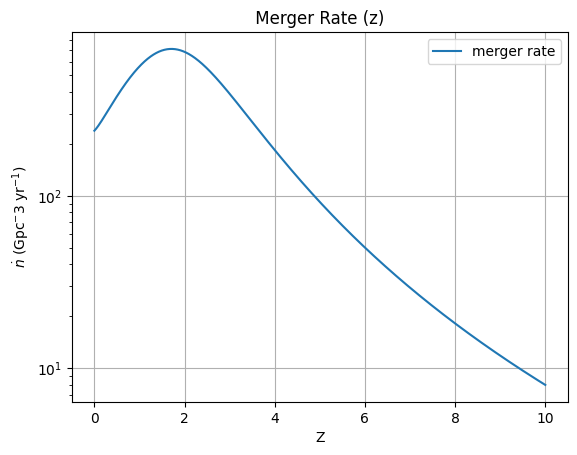

In [10]:
redshift_basevals = np.linspace(0.001,10,1000)
ndotvalues = [mergerrate(zm, -1.0, 0.01, 14) for zm in redshift_basevals]
plt.plot(redshift_basevals, ndotvalues, label='merger rate')
plt.ylabel('$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)')
plt.xlabel('Z')
plt.yscale('log')
plt.legend()
plt.title(' Merger Rate (z) ')

#plt.xlim(0,10)
#plt.ylim(10,20e2)
plt.grid(True, axis = 'both')

okay so I want to be able to generate populations and measure differences between them
some things I gotta check before that:
make sure the pupulation from different dtd slopes is accurate or check if the rates are just unreaslistic or whats goin on there
might want to consider streamlining the wole code into 1 cell and downloading the json file to keep the population data

Next:
what parameters I should test!

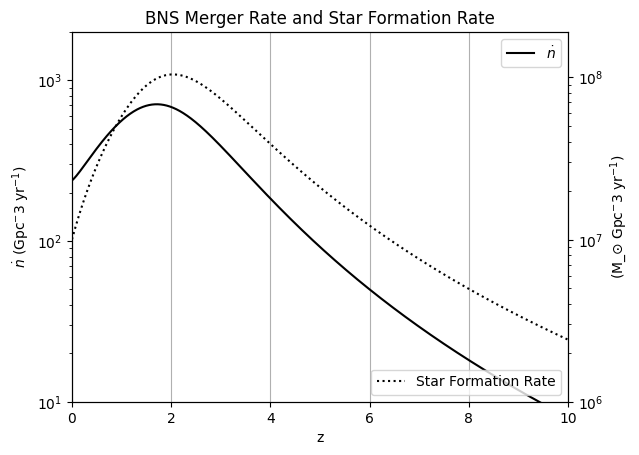

In [11]:
#Comparison to SFR
fig, ax1 = plt.subplots()
ax1.set_xlabel('z')
ax1.set_ylabel('$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)')
ax1.plot(redshift_basevals, ndotvalues, color = 'black', label = '$\dot{n}$')
ax1.set_yscale('log')
ax1.set_xlim(0,10)
ax1.set_ylim(10, 2000)
ax1.legend()
ax1.grid(axis = 'y')
ax1.grid(axis = 'x')

ax2 = ax1.twinx()

color = 'tab:black'
ax2.set_ylabel('(M_${\odot}$ Gpc$^{-}3$ yr$^{-1}$)')
ax2.plot(redshift_basevals,sfr_mf_bins, color = 'black', label = 'Star Formation Rate', linestyle = 'dotted')
ax2.set_yscale('log')
ax2.set_ylim(1e6, 19e7)
plt.title('BNS Merger Rate and Star Formation Rate')
ax2.legend(loc = 'lower right')
ax1.grid(axis = 'y')
ax2.grid(axis = 'x')


##Population Code

In [12]:
def population_generator(sfr, zm, slope, tmin, tmax, zrange):
    redshift_basevals = np.linspace(0.001,tmax,1000)
    mergerratevalues = [mergerrate(zm, slope, tmin, tmax) for zm in redshift_basevals]
    

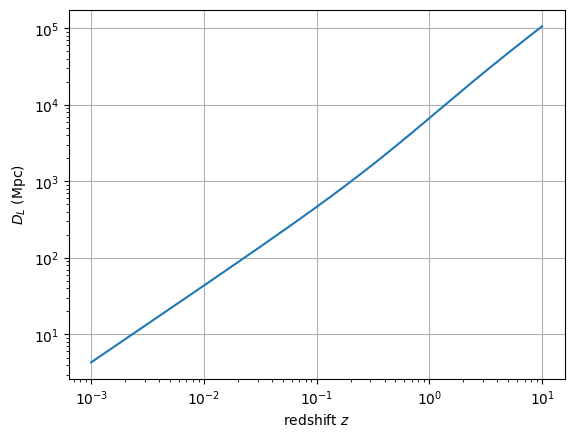

In [13]:
dz_base = redshift_basevals[1] #maybe wanna subtract the reshift basevals [0] to get the step size

lumdist_basevals = cosmo.luminosity_distance(redshift_basevals).value
scale_factor_basevals =   cosmo.scale_factor(redshift_basevals)
diff_Vc_basevals = 4.0 * np.pi * (cosmo.differential_comoving_volume(redshift_basevals).value)
#above is 4 pi r? maybe should be 4pi r squared?

plt.loglog(redshift_basevals,lumdist_basevals)
plt.xlabel("redshift $z$")
plt.ylabel("$D_L$ (Mpc)")
plt.grid()

In [14]:
#adjusting for local rate

localrate = 200 / np.power(1000,3) # rate / Gpc^3 / yr , converted to 1000^3 Mpc^3 / Gpc^3

rate_scale = localrate / mergerrate(0.01,-1, 0.01, 14)*10**9 ##multiply by 10**9 to get it in Mpc
print("Scaling to estimated local rate", localrate ,"requires a factor of",rate_scale)

Scaling to estimated local rate 2e-07 requires a factor of 0.8339387144587848


Text(0.5, 1.0, 'Merger Rate Over Z adjusted for local rate')

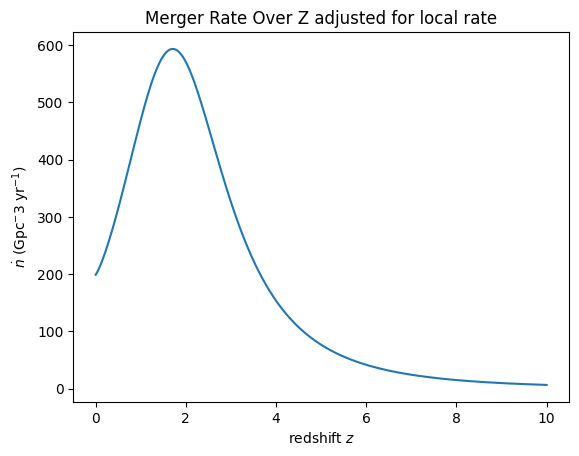

In [15]:
plt.plot(redshift_basevals, rate_scale*np.array(ndotvalues))
plt.xlabel("redshift $z$")
plt.ylabel("$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)")
plt.title('Merger Rate Over Z adjusted for local rate')

Text(0.5, 1.0, 'Mergers per unit Z')

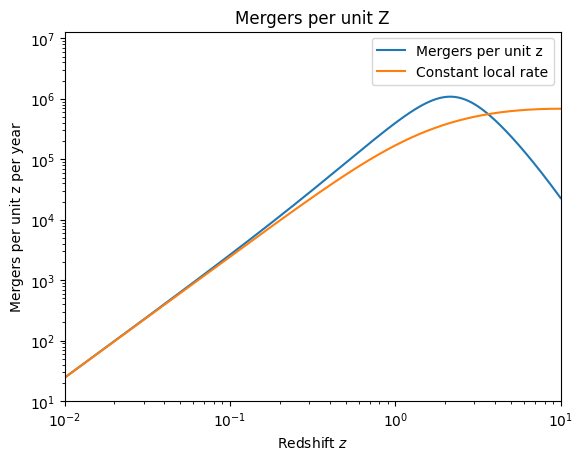

In [16]:
dNdz_basevals = diff_Vc_basevals * ndotvalues *10**-9 / scale_factor_basevals
plt.loglog(redshift_basevals, dNdz_basevals ,label="Mergers per unit z")
plt.loglog(redshift_basevals, mergerrate(0.01, -1, 0.01, 14) *10**-9* diff_Vc_basevals/ scale_factor_basevals,label="Constant local rate")
plt.xlabel("Redshift $z$")
plt.ylabel("Mergers per unit z per year")
plt.legend()
plt.xlim(0.01,10)
plt.ylim(10,13e6)
plt.title('Mergers per unit Z')

Text(0.5, 1.0, 'Mergers per unit Z adjusted for local rate')

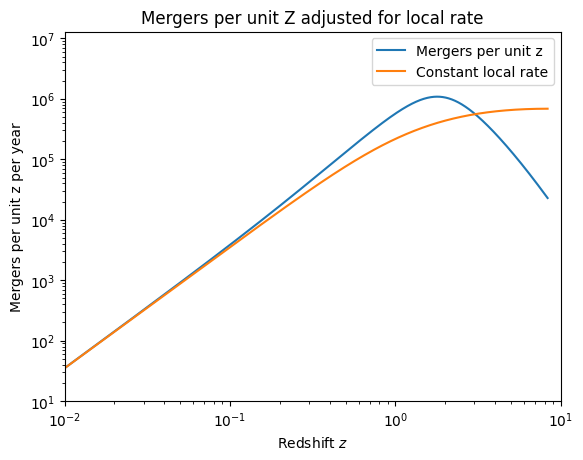

In [17]:
dNdz_basevals = diff_Vc_basevals * ndotvalues *10**-9 / scale_factor_basevals
plt.loglog(rate_scale*redshift_basevals, dNdz_basevals ,label="Mergers per unit z")
plt.loglog(rate_scale*redshift_basevals, mergerrate(0.01, -1, 0.01, 14) *10**-9* diff_Vc_basevals/ scale_factor_basevals,label="Constant local rate")

# I feel like the rate scale should be multiplied to the y axis, but that doesnt change my numbers anyway
#mergers per unit Z per YEAR, so these are all the mergers happening over the course of Z that we will end up seeing TODAY, so 2.8 million per year is nice because we're considering
#over all z
plt.xlabel("Redshift $z$")
plt.ylabel("Mergers per unit z per year")
plt.legend()
plt.xlim(0.01,10)
plt.ylim(10,13e6)
plt.title('Mergers per unit Z adjusted for local rate')

In [18]:
dz_base = (redshift_basevals[1]-redshift_basevals[0])
totalmergers = rate_scale * sum(dNdz_basevals) * dz_base

print('total mergers ->',totalmergers,'sum Dndz basevals ->', sum(dNdz_basevals),'dz base->', dz_base, 'rate scale->', rate_scale )

total mergers -> 2748037.737430144 sum Dndz basevals -> 329228540.24113286 dz base-> 0.010009009009009008 rate scale-> 0.8339387144587848


###Rate Statements


In [19]:
print("There are" ,'{0:1.2g}'.format(totalmergers), "DNS merger GWs per year from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365*7), "DNS merger GWs per week from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365), "DNS merger GWs per day from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365/24), "DNS merger GWs per hour from this Universe.")
print("There are" ,'{0:1.2g}'.format(totalmergers/365/24/60), "DNS merger GWs per minute from this Universe.")

There are 2.7e+06 DNS merger GWs per year from this Universe.
There are 5.3e+04 DNS merger GWs per week from this Universe.
There are 7.5e+03 DNS merger GWs per day from this Universe.
There are 3.1e+02 DNS merger GWs per hour from this Universe.
There are 5.2 DNS merger GWs per minute from this Universe.


In [ ]:
nearred = 0.2
nearbymergers = rate_scale * sum(dNdz_basevals[redshift_basevals<nearred]) * redshift_basevals[1]
print("There are" ,'{0:1.2g}'.format(nearbymergers), "DNS GWs per year with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365*7), "DNS GWs per week with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365), "DNS GWs per day with z<",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365/24), "DNS GWs per hour with z<",nearred)
print ("( or D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc)")

There are 6.3e+02 DNS GWs per year with z< 0.2
There are 12 DNS GWs per week with z< 0.2
There are 1.7 DNS GWs per day with z< 0.2
There are 0.072 DNS GWs per hour with z< 0.2
( or D < 992 Mpc)


In [21]:
nearred = 0.1
nearbymergers = rate_scale * sum(dNdz_basevals[redshift_basevals<nearred]) * redshift_basevals[1]
print("There are" ,'{0:1.2g}'.format(nearbymergers), "DNS mergers per year with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365*7), "DNS mergers per week with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365), "DNS mergers per day with z <",nearred)
print("There are" ,'{0:1.2g}'.format(nearbymergers/365/24), "DNS mergers per hour with z <",nearred)
print ("( or D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc)")

There are 69 DNS mergers per year with z < 0.1
There are 1.3 DNS mergers per week with z < 0.1
There are 0.19 DNS mergers per day with z < 0.1
There are 0.0079 DNS mergers per hour with z < 0.1
( or D < 465 Mpc)


In [22]:
#local rate statistics
print("Constant rate of",'{0:1.3g}'.format(localrate*np.power(1000.,3)),"/ Gpc^3 / yr, with cosmological volume:")
for nearred in (0.01,0.05,0.1):
  print(" . ",'{0:1.2g}'.format(cosmo.comoving_volume(nearred).value * localrate),
        "per year with z <",nearred, "and D <",'{0:1.3g}'.format(cosmo.luminosity_distance(nearred).value), "Mpc")

Constant rate of 200 / Gpc^3 / yr, with cosmological volume:
 .  0.067 per year with z < 0.01 and D < 43.6 Mpc
 .  8.2 per year with z < 0.05 and D < 225 Mpc
 .  63 per year with z < 0.1 and D < 465 Mpc


In [23]:
print("GW170817-like signal every ",1 /( cosmo.comoving_volume(0.01).value * localrate),"years.")

GW170817-like signal every  14.85269440357986 years.


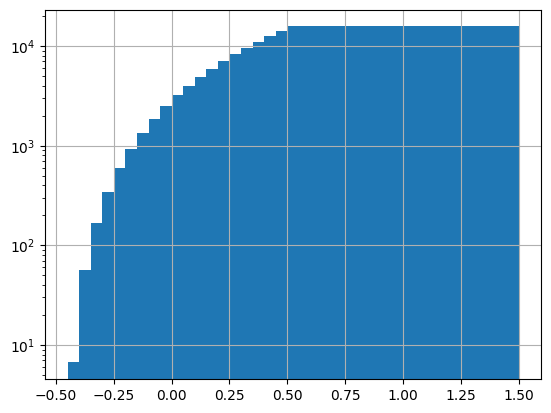

In [24]:
redshift_plot = np.linspace(0,1,21)
ratebins_plot = np.array([rate_scale * sum(dNdz_basevals[redshift_basevals<rs])* dz_base for rs in redshift_plot])

plt.bar(redshift_plot[1:],ratebins_plot[1:] - ratebins_plot[:-1],width=1)
plt.grid()
plt.yscale('log')

##Target Population

In [25]:
nsamples = 840000 # Can't really resolve both CE and ALIGO;
# I'll just look at subpopulations below, but there is probably a clever analytic way to do this
near = 0.5
sampletime = nsamples/ (rate_scale * sum(dNdz_basevals) * dz_base)
sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)
print(nsamples,"mergers occur every ",'{0:1.3g}'.format(sampletime*365), "days in the Universe")
print(nsamples,"mergers occur every ",'{0:1.3g}'.format(sampletime_nearby) , "years with z <",near)


840000 mergers occur every  112 days in the Universe
840000 mergers occur every  76.5 years with z < 0.5


In [26]:
fiducial_time = 5 # five year survey
nearby_survey = int(nsamples * fiducial_time / sampletime_nearby)
print(nearby_survey)

54913


In [27]:
fiducial_time = 1 # one year survey
nearby_survey = int(nsamples * fiducial_time / sampletime_nearby)
print(nearby_survey)

10982


##Extrinsic Parameters

In [28]:
redshifts = np.random.choice(redshift_basevals,nsamples, p=dNdz_basevals/sum(dNdz_basevals))
redshifts_nearby = np.random.choice(redshift_basevals[redshift_basevals<near],nsamples,
                                    p=dNdz_basevals[redshift_basevals<near]/sum(dNdz_basevals[redshift_basevals<near]))

lumdists = cosmo.luminosity_distance(redshifts).value
lumdists_nearby = cosmo.luminosity_distance(redshifts_nearby).value

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/960524086.py:33: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(littleomega) #can use this for both nearby and full populations


Text(0.5, 0, '$\\omega$')

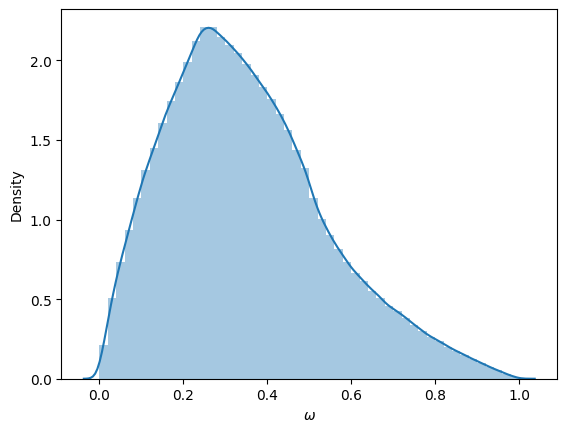

In [29]:
# Now let's randomly assign sky direction, polarization, and inclination

# Code very slightly modified from Davide Gerosa's
# https://github.com/dgerosa/gwdet/blob/master/gwdet/gwdet.py
# used generate samples with random sky location, polarization, and inclination

# Sample the angles according to their pdf
theta= np.arccos(np.random.uniform(-1,1,nsamples)) #Sky loc  # Polar
phi =  np.pi*np.random.uniform(-1,1,nsamples)      #Sky loc  # Azimuthal
psi =  np.pi*np.random.uniform(-1,1,nsamples)     #Polarization    # Azimuthal
iota = np.arccos(np.random.uniform(-1,1,nsamples))  #Inclination  Polar
# From 0903.0338: if one wants the antenna pattern referred to the detector’s own axes, then one just sets polarization ψ = 0.

# Antenna patterns. Eq. (57) in arxiv:0903.0338
Fplus  = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.cos(2.*psi) - np.cos(theta)*np.sin(2.*phi)*np.sin(2.*psi)
Fcross = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.sin(2.*psi) + np.cos(theta)*np.sin(2.*phi)*np.cos(2.*psi)
# antenna-pattern response functions of the interferometer to the two polarizations of the wave as defined in the sky plane

# Projection parameter. Eq. (3.31) in arxiv:gr-qc/9301003 but define littleomega=Theta/4
# so that the optimal signal has littleomega=1
littleomega = ( Fplus**2*(1.+np.cos(iota)**2)**2/4. +Fcross**2*np.cos(iota)**2 )**0.5
# using notation of https://arxiv.org/pdf/1405.7016.pdf
# projection for circular (elliptical?) polarizations

# The resulting snr of a signal will be rho = littleomega * rho_opt
# where rho_opt is the SNR of an optimally oriented binary at the given distance

avg_omega = sum(littleomega)/len(littleomega)

effective_dists = lumdists / littleomega
effective_dists_nearby = lumdists_nearby / littleomega

sns.distplot(littleomega) #can use this for both nearby and full populations
plt.xlabel("$\omega$")

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/729504036.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(littleomega) #can use this for both nearby and full populations


Text(0.5, 0, '$\\omega$')

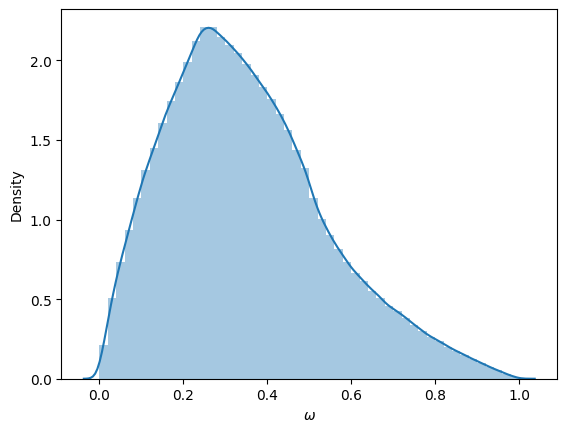

In [30]:
sns.distplot(littleomega) #can use this for both nearby and full populations
plt.xlabel("$\omega$")

In [31]:
avg_omega = sum(littleomega)/len(littleomega)
effective_dists = lumdists / littleomega
effective_dists_nearby = lumdists_nearby / littleomega

# Intrinsic parameters

In [32]:
mAs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
mBs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
# independent draws from the distribution
#swap out for other mass models
#using bimodal mass distribution parameters from Landry and Read

In [33]:
mheavy = np.array([max(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])
mlight = np.array([min(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])

In [34]:
mchirps = [mchirp_from_mass1_mass2(mass1, mass2) for (mass1, mass2) in np.array((mAs, mBs)).T]
mchirps = np.array(mchirps)

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/3635463249.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(mchirps)


Text(1.444, 1, 'GW190425')

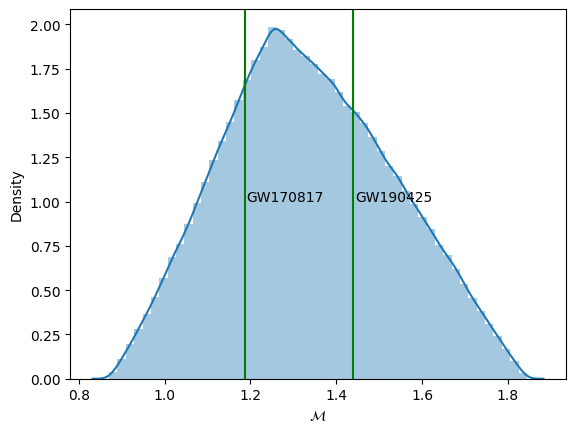

In [35]:
sns.distplot(mchirps)
plt.xlabel("$\mathcal{M}$")
plt.axvline(1.44,color="green")
plt.axvline(1.188,color="green")
plt.annotate('GW170817',xy=(1.1892,1))
plt.annotate('GW190425',xy=(1.444,1))

Fiducial System

In [36]:
flow =10 # Negligible SNR below this

fiducial_mass = 1.36 # Redshifted, detector frame
reference_Deff = 100
fiducial_mchirp = mchirp_from_mass1_mass2(fiducial_mass,fiducial_mass)
deltaf=5.0
sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=fiducial_mass, mass2=fiducial_mass,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)

In [37]:
flen = len(sptilde_fid)
DetectorRhoList = []
for detname in DetectorNames:
  detpsd = psd.read.from_numpy_arrays(DetectorPSDData[detname][:,0],DetectorPSDData[detname][:,1],flen,deltaf,flow)
  rhosq = sigmasq(sptilde_fid,detpsd,flow)
  DetectorRhoList.append(np.sqrt(rhosq))
DetectorRho = dict(zip(DetectorNames, DetectorRhoList))
DetectorRho

{'ALIGO': np.float64(34.01396660071108),
 'APLUS': np.float64(65.29001628653383),
 'Voyager': np.float64(147.95266636770606),
 'CE': np.float64(1184.1979946201977)}

In [38]:
# Fiducial mismatch tolerance:
dict(zip(DetectorNames,[1/2/np.power(rho,2) for rho in DetectorRho.values()]))

# Fiducial systems at increasing effective distance
SNR_opt_of_redshift = {}
lowind=1

In [39]:
for detector in ['CE','Voyager','APLUS','ALIGO']:
  SNR_opt_of_redshift[detector] = [ DetectorRho[detector] * np.power(
    scale_factor_basevals[i] , 5./6.) * reference_Deff / lumdist_basevals[i] for i in range(len(redshift_basevals))[lowind:]]


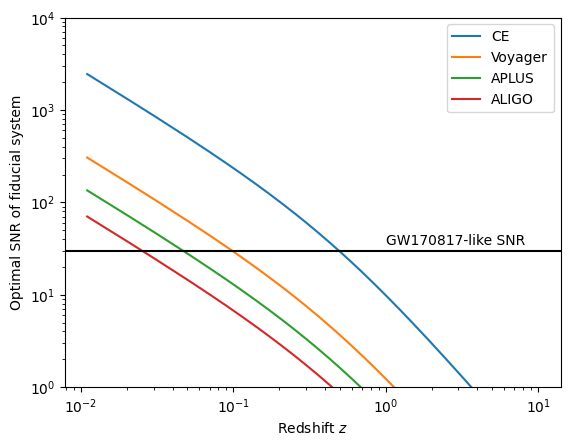

In [40]:
for detector in ['CE','Voyager','APLUS','ALIGO']:
  plt.loglog(redshift_basevals[lowind:],SNR_opt_of_redshift[detector],label=detector)
plt.xlabel("Redshift $z$")
plt.ylabel("Optimal SNR of fiducial system")
plt.axhline(30,color="black")
plt.annotate('GW170817-like SNR',xy=(1,30+5))
plt.ylim(1,1e4)
plt.legend(loc="upper right")

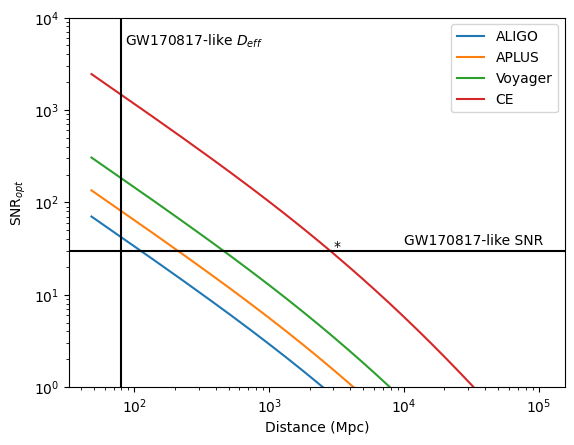

In [41]:
for detector in ['ALIGO','APLUS','Voyager','CE',]:
  plt.loglog(lumdist_basevals[lowind:],SNR_opt_of_redshift[detector],label=detector)
plt.xlabel("Distance (Mpc)")
plt.ylabel("SNR$_{opt}$")
plt.axhline(30,color="black")
plt.annotate('GW170817-like SNR',xy=(10000,30+5))
plt.axvline(80,color="black")
plt.annotate('GW170817-like $D_{eff}$',xy=(80+5,5000))
plt.annotate('*',xy=(3000,30))
plt.ylim(1,1e4)
plt.legend(loc="upper right")

Full Population SNRs

Now, let's consider the full population - SNR will depend primarily on redshifted chirp mass and on the effective distance (luminosity distance / sky factor ω).

Effective distance scaling is just ρ=ρ0Deff,0Deff.

For inspiral-dominated signals, SNR scales as ρ=ρ0(MzMz,0)5/6

Scaling nicely explained & referenced in https://arxiv.org/pdf/1108.5161.pdf

In [44]:
CESNRs = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)

CESNRs_nearby = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

APLUSSNRs = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
APLUSSNRs_nearby = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

ALIGOSNRs_nearby = DetectorRho['ALIGO'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

VoyagerSNRs = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
VoyagerSNRs_nearby = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

# Mchirp scaling breaks down for CE
# Make a quick fit
from scipy import interpolate
from pycbc.conversions import mass1_from_mchirp_q
mchList = np.linspace(
    mchirp_from_mass1_mass2(mminNS,mminNS), #lowest possible
    mchirp_from_mass1_mass2(mmaxNS,mmaxNS) * (1+redshift_basevals[-1]), #highest possible
    #1.01*max(mchirps*(1+redshifts)), # highest to encounter in full pop
    20) #Range of detector-frame (redshifted) chirp masses
refrhoList = []
for i, mch in enumerate(mchList):
  mref = mass1_from_mchirp_q(mch,1) #equal mass q=1
  sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=mref, mass2=mref,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
  flen = len(sptilde_fid)
  detpsd = psd.read.from_numpy_arrays(DetectorPSDData['CE'][:,0],DetectorPSDData['CE'][:,1],
                                      flen,deltaf,flow)
  rhosq = sigmasq(sptilde_fid,detpsd,flow)
  refrhoList.append(np.sqrt(rhosq))
  
rho_of_mchirp_ref = interpolate.interp1d(mchList, refrhoList)
horizondist = reference_Deff * np.array(refrhoList) / 8.0
horizonredshift = [z_at_value(cosmo.luminosity_distance, dist *u.Mpc) for dist in horizondist]

CESNRs_mchirp = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts))
    )* littleomega * reference_Deff / np.array(lumdists)
CESNRs_mchirp_nearby = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts_nearby))
    )* littleomega * reference_Deff / np.array(lumdists_nearby)

In [45]:
CESNRs_nearby = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

In [46]:
APLUSSNRs = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
APLUSSNRs_nearby = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

In [47]:
ALIGOSNRs_nearby = DetectorRho['ALIGO'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

In [48]:
VoyagerSNRs = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
VoyagerSNRs_nearby = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

In [49]:
# Mchirp scaling breaks down for CE
# Make a quick fit
from pycbc.conversions import mass1_from_mchirp_q
mchList = np.linspace(
    mchirp_from_mass1_mass2(mminNS,mminNS), #lowest possible
    mchirp_from_mass1_mass2(mmaxNS,mmaxNS) * (1+redshift_basevals[-1]), #highest possible
    #1.01*max(mchirps*(1+redshifts)), # highest to encounter in full pop
    20) #Range of detector-frame (redshifted) chirp masses


In [50]:
refrhoList = []
for i, mch in enumerate(mchList):
  mref = mass1_from_mchirp_q(mch,1) #equal mass q=1
  sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=mref, mass2=mref,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
  flen = len(sptilde_fid)
  detpsd = psd.read.from_numpy_arrays(DetectorPSDData['CE'][:,0],DetectorPSDData['CE'][:,1],
                                      flen,deltaf,flow)
  rhosq = sigmasq(sptilde_fid,detpsd,flow)
  refrhoList.append(np.sqrt(rhosq))

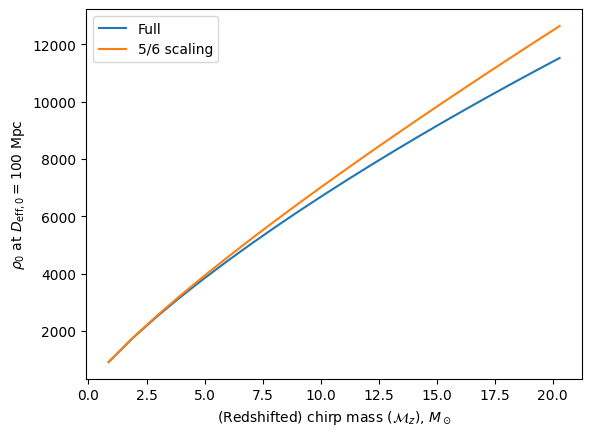

In [51]:
plt.plot(mchList,refrhoList, label="Full")
plt.plot(mchList, DetectorRho['CE'] * np.power(mchList/fiducial_mchirp,5./6.),label="5/6 scaling")
plt.xlabel("(Redshifted) chirp mass ($\mathcal{M}_z$), $M_\odot$")
plt.ylabel(r'$\rho_0$ at $D_{\mathrm{eff},0}=100$ Mpc')
plt.legend()
from scipy import interpolate
rho_of_mchirp_ref = interpolate.interp1d(mchList, refrhoList)


Text(0, 0.5, 'Horizon (Mpc)')

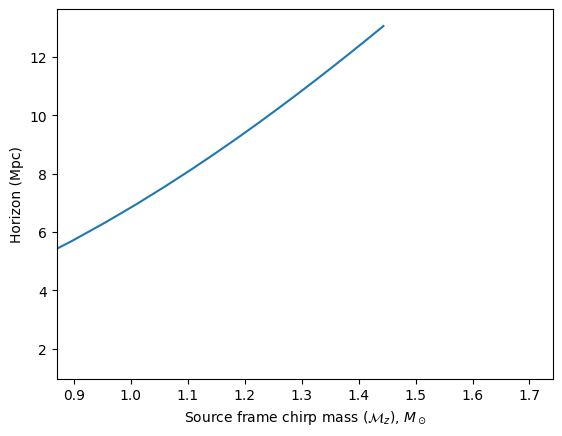

In [52]:
horizondist = reference_Deff * np.array(refrhoList) / 8.0
horizonredshift = [z_at_value(cosmo.luminosity_distance, dist *u.Mpc) for dist in horizondist]
plt.plot(np.array(mchList)/(1+np.array(horizonredshift)) ,horizonredshift)
plt.xlim(mchirp_from_mass1_mass2(1.0,1.0),mchirp_from_mass1_mass2(2.0,2.0))
plt.xlabel("Source frame chirp mass ($\mathcal{M}_z$), $M_\odot$")
plt.ylabel(r'Horizon (Mpc)')

In [53]:
CESNRs_mchirp = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts))
    )* littleomega * reference_Deff / np.array(lumdists)
CESNRs_mchirp_nearby = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts_nearby))
    )* littleomega * reference_Deff / np.array(lumdists_nearby)

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/2145776130.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.array(mchirps[CESNRs>1])*(1+redshifts[CESNRs>1]), kde=False,norm_hist=False,label="All CE frame")
/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/2145776130.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.co

(1.0, 7.0)

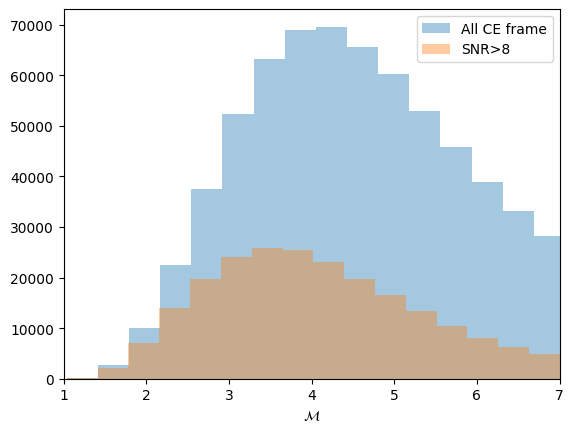

In [54]:
sns.distplot(np.array(mchirps[CESNRs>1])*(1+redshifts[CESNRs>1]), kde=False,norm_hist=False,label="All CE frame")
sns.distplot(mchirps[CESNRs>8] *(1+redshifts[CESNRs>8]),kde=False, norm_hist=False, label="SNR>8")
# Still inspiral dominated even out to the tail?
plt.xlabel('$\mathcal{M}$')
plt.legend()
plt.xlim(1,7)

Number of Detections

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/1208591511.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(lumdists_nearby[:nearby_survey]/1000, kde=False,label="Universe")
/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/1208591511.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

(0.0, 3.0)

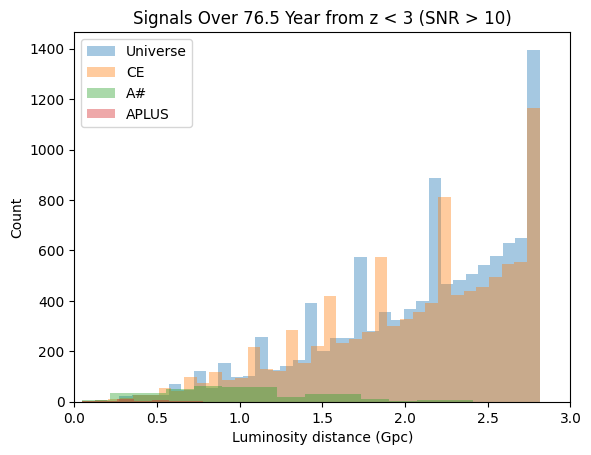

In [55]:
sns.distplot(lumdists_nearby[:nearby_survey]/1000, kde=False,label="Universe")
sns.distplot(lumdists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="CE")
sns.distplot(lumdists_nearby[:nearby_survey][VoyagerSNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="A#")
sns.distplot(lumdists_nearby[:nearby_survey][APLUSSNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="APLUS")
plt.legend()
plt.xlabel('Luminosity distance (Gpc)')
plt.title('Signals Over '+'{0:1.3g}'.format(sampletime_nearby)+' Year from z < 3 (SNR > 10)')
plt.ylabel('Count')
plt.xlim(0,3)
#plt.ylim(0, 10000)

/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/137853376.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(effective_dists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="CE")
/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/137853376.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/

Text(0.5, 1.0, 'Signals Over 76.5 Year from z < 3')

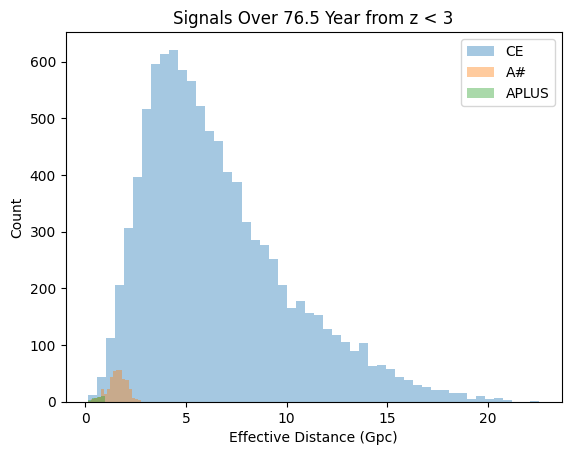

In [56]:
 #sns.distplot(effective_dists_nearby[:nearby_survey]/1000, kde=False,label="Universe")
sns.distplot(effective_dists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="CE")
sns.distplot(effective_dists_nearby[:nearby_survey][VoyagerSNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="A#")
sns.distplot(effective_dists_nearby[:nearby_survey][APLUSSNRs_nearby[:nearby_survey]>10]/1000, kde=False,label="APLUS")
plt.legend()
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel("Count")
plt.title('Signals Over '+'{0:1.3g}'.format(sampletime_nearby)+' Year from z < 3')

#plt.xlim(0,2.5)

In [57]:
data = effective_dists_nearby[:nearby_survey][VoyagerSNRs_nearby[:nearby_survey]>10]/1000
data_to_save = data.tolist()
len(data_to_save)

406

In [91]:
def population_generator(slope, tmin, tmax, zrange, localrate, surveytime, snr, dzstep):
    redshift_basevals = np.linspace(0.001,10,dzstep)
    mergerratevalues = [mergerrate(zm, slope, tmin, tmax) for zm in redshift_basevals]

    fig, ax1 = plt.subplots()
    ax1.set_xlabel('z')
    ax1.set_ylabel('$\dot{n}$ (Gpc$^{-}3$ yr$^{-1}$)')
    ax1.plot(redshift_basevals, mergerratevalues, color = 'black', label = '$\dot{n}$')
    ax1.set_yscale('log')
    ax1.set_xlim(0,10)
    ax1.set_ylim(10, 2000)
    ax1.legend()
    ax1.grid(axis = 'y')
    ax1.grid(axis = 'x')

    ax2 = ax1.twinx()

    color = 'tab:black'
    ax2.set_ylabel('(M_${\odot}$ Gpc$^{-}3$ yr$^{-1}$)')
    ax2.plot(redshift_basevals,sfr_mf_bins, color = 'black', label = 'Star Formation Rate', linestyle = 'dotted')
    ax2.set_yscale('log')
    ax2.set_ylim(1e6, 19e7)
    plt.title('BNS Merger Rate and Star Formation Rate')
    ax2.legend(loc = 'lower right')
    ax1.grid(axis = 'y')
    ax2.grid(axis = 'x')


    localrate # rate / Gpc^3 / yr , converted to 1000^3 Mpc^3 / Gpc^3
    rate_scale = localrate / mergerrate(0.01,-1, 0.01, 14)*10**9 ##multiply by 10**9 to get it in Mpc
    print("Scaling to estimated local rate", localrate ,"requires a factor of",rate_scale)

    
    lumdist_basevals = cosmo.luminosity_distance(redshift_basevals).value
    scale_factor_basevals =  cosmo.scale_factor(redshift_basevals)
    diff_Vc_basevals = 4.0 * np.pi * (cosmo.differential_comoving_volume(redshift_basevals).value)
    dz_base = (redshift_basevals[1]-redshift_basevals[0]) # this is our step size for our dz
    dNdz_basevals = diff_Vc_basevals * mergerratevalues *10**-9 / scale_factor_basevals
    totalmergers = round(rate_scale * sum(dNdz_basevals)*dz_base)
    print('Total mergers per year from this universe ->',totalmergers)

    nsamples = int(totalmergers)
    near = zrange
    sampletime = nsamples/(rate_scale * sum(dNdz_basevals) * dz_base)

    
    sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)
    nyearsampletotal = nsamples*surveytime/(sampletime)
    print("There are " + str(nyearsampletotal) + "mergers in " + str(surveytime) + " years in this universe. ")

    print ("The nearby sample time is " + str(sampletime_nearby) )
    fiducial_time = surveytime # one year survey
    nearby_survey = int(nsamples * fiducial_time / sampletime_nearby)
    print(nearby_survey)
    
    nyearsamplenear = nsamples*surveytime/(sampletime_nearby)
    print("There are " + str(nyearsamplenear) + "mergers in " + str(surveytime) + " years in this universe with z < " + str(zrange))

    nsamples = int(nyearsamplenear)
    sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)

    redshifts = np.random.choice(redshift_basevals,nsamples, p=dNdz_basevals/sum(dNdz_basevals))
    redshifts_nearby = np.random.choice(redshift_basevals[redshift_basevals<near],nsamples,
                                    p=dNdz_basevals[redshift_basevals<near]/sum(dNdz_basevals[redshift_basevals<near]))

    lumdists = cosmo.luminosity_distance(redshifts).value
    lumdists_nearby = cosmo.luminosity_distance(redshifts_nearby).value


    # Sample the angles according to their pdf
    theta= np.arccos(np.random.uniform(-1,1,nsamples)) #Sky loc  # Polar
    phi =  np.pi*np.random.uniform(-1,1,nsamples)      #Sky loc  # Azimuthal
    psi =  np.pi*np.random.uniform(-1,1,nsamples)     #Polarization    # Azimuthal
    iota = np.arccos(np.random.uniform(-1,1,nsamples))  #Inclination  Polar
    # From 0903.0338: if one wants the antenna pattern referred to the detector’s own axes, then one just sets polarization ψ = 0.

    # Antenna patterns. Eq. (57) in arxiv:0903.0338
    Fplus  = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.cos(2.*psi) - np.cos(theta)*np.sin(2.*phi)*np.sin(2.*psi)
    Fcross = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.sin(2.*psi) + np.cos(theta)*np.sin(2.*phi)*np.cos(2.*psi)
    # antenna-pattern response functions of the interferometer to the two polarizations of the wave as defined in the sky plane

    # Projection parameter. Eq. (3.31) in arxiv:gr-qc/9301003 but define littleomega=Theta/4
    # so that the optimal signal has littleomega=1
    littleomega = ( Fplus**2*(1.+np.cos(iota)**2)**2/4. +Fcross**2*np.cos(iota)**2 )**0.5
    # using notation of https://arxiv.org/pdf/1405.7016.pdf
    # projection for circular (elliptical?) polarizations

    # The resulting snr of a signal will be rho = littleomega * rho_opt
    # where rho_opt is the SNR of an optimally oriented binary at the given distance

    avg_omega = sum(littleomega)/len(littleomega)
    effective_dists = lumdists / littleomega
    effective_dists_nearby = lumdists_nearby / littleomega

    mAs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
    mBs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
    # independent draws from the distribution
    #swap out for other mass models
    #using bimodal mass distribution parameters from Landry and Read
    mheavy = np.array([max(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])
    mlight = np.array([min(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])

    mchirps = [mchirp_from_mass1_mass2(mass1, mass2) for (mass1, mass2) in np.array((mAs, mBs)).T]
    mchirps = np.array(mchirps) 
    flow =10 # Negligible SNR below this

    fiducial_mass = 1.36 # Redshifted, detector frame
    reference_Deff = 100
    fiducial_mchirp = mchirp_from_mass1_mass2(fiducial_mass,fiducial_mass)
    deltaf=5.0
    sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=fiducial_mass, mass2=fiducial_mass,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
    
    flen = len(sptilde_fid)
    DetectorRhoList = []
    for detname in DetectorNames:
      detpsd = psd.read.from_numpy_arrays(DetectorPSDData[detname][:,0],DetectorPSDData[detname][:,1],flen,deltaf,flow)
      rhosq = sigmasq(sptilde_fid,detpsd,flow)
      DetectorRhoList.append(np.sqrt(rhosq))
    DetectorRho = dict(zip(DetectorNames, DetectorRhoList))
    
    # Fiducial mismatch tolerance:
    dict(zip(DetectorNames,[1/2/np.power(rho,2) for rho in DetectorRho.values()]))

    # Fiducial systems at increasing effective distance
    SNR_opt_of_redshift = {}
    lowind=1

    for detector in ['CE','Voyager','APLUS','ALIGO']:
      SNR_opt_of_redshift[detector] = [ DetectorRho[detector] * np.power(
      scale_factor_basevals[i] , 5./6.) * reference_Deff / lumdist_basevals[i] for i in range(len(redshift_basevals))[lowind:]]
  
    CESNRs = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)

    CESNRs_nearby = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    APLUSSNRs = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
    APLUSSNRs_nearby = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    ALIGOSNRs_nearby = DetectorRho['ALIGO'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    VoyagerSNRs = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
    VoyagerSNRs_nearby = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    # Mchirp scaling breaks down for CE
    # Make a quick fit
    from pycbc.conversions import mass1_from_mchirp_q
    mchList = np.linspace(
    mchirp_from_mass1_mass2(mminNS,mminNS), #lowest possible
    mchirp_from_mass1_mass2(mmaxNS,mmaxNS) * (1+redshift_basevals[-1]), #highest possible
    #1.01*max(mchirps*(1+redshifts)), # highest to encounter in full pop
    20) #Range of detector-frame (redshifted) chirp masses

    refrhoList = []
    for i, mch in enumerate(mchList):
        mref = mass1_from_mchirp_q(mch,1) #equal mass q=1
        sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=mref, mass2=mref,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
        flen = len(sptilde_fid)
        detpsd = psd.read.from_numpy_arrays(DetectorPSDData['CE'][:,0],DetectorPSDData['CE'][:,1],
                                      flen,deltaf,flow)
        rhosq = sigmasq(sptilde_fid,detpsd,flow)
        refrhoList.append(np.sqrt(rhosq))

    horizondist = reference_Deff * np.array(refrhoList) / 8.0
    horizonredshift = [z_at_value(cosmo.luminosity_distance, dist *u.Mpc) for dist in horizondist]

    CESNRs_mchirp = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts))
    )* littleomega * reference_Deff / np.array(lumdists)
    CESNRs_mchirp_nearby = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts_nearby))
    )* littleomega * reference_Deff / np.array(lumdists_nearby)

    plt.figure()
    sns.distplot(lumdists_nearby[:nearby_survey]/1000, kde=False,label="Universe")
    sns.distplot(lumdists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="CE")
    sns.distplot(lumdists_nearby[:nearby_survey][VoyagerSNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="A#")
    sns.distplot(lumdists_nearby[:nearby_survey][APLUSSNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="APLUS")
    plt.legend()
    plt.xlabel('Luminosity distance (Gpc)')
    plt.title('Signals Over '+'{0:1.3g}'.format(sampletime_nearby)+' Year from z < ' + str(zrange) + ' with SNR > ' + str(snr) )
    plt.ylabel('Count')
    plt.xlim(0,np.max(lumdists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>snr]/1000))
    #plt.ylim(0, 10000)
    
    plt.figure()
    sns.distplot(effective_dists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="CE")
    sns.distplot(effective_dists_nearby[:nearby_survey][VoyagerSNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="A#")
    sns.distplot(effective_dists_nearby[:nearby_survey][APLUSSNRs_nearby[:nearby_survey]>snr]/1000, kde=False,label="APLUS")
    plt.legend()
    plt.xlabel('Effective Distance (Gpc)')
    plt.ylabel("Count")
    plt.title('Signals Over '+'{0:1.3g}'.format(sampletime_nearby)+' Year from z < ' + str(zrange) + ' with SNR > ' + str(snr) )

    data = effective_dists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>snr]/1000
    data_to_save = data.tolist()
    print("This is a BNS CE detectable population for a DTD slope of " + str(slope) + ", a minimum time delay of " + str(tmin) + ", up to a z value of"  + str(zrange) + " for a survey time of " + str(surveytime))
    
    return data_to_save

    
    

Scaling to estimated local rate 2e-07 requires a factor of 0.8339387144587848
Total mergers per year from this universe -> 2748038
There are 2748037.7374301436mergers in 1 years in this universe. 
The nearby sample time is 1.7185365310266665
1599057
There are 1599057.0758238707mergers in 1 years in this universe with z < 3
This is a BNS CE detectable population for a DTD slope of -1, a minimum time delay of 0.01, up to a z value of3 for a survey time of 1


/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/61501887.py:192: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(lumdists_nearby[:nearby_survey]/1000, kde=False,label="Universe")
/var/folders/v2/sqb0b1055zd7wgsnsmjgfbf00000gn/T/ipykernel_1670/61501887.py:193: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750

[28.06589259664393,
 17.9295024467108,
 18.95715672147511,
 23.64156689817351,
 22.027873831667698,
 19.682949056214472,
 18.441225716619755,
 17.0757781702041,
 29.23563988126329,
 22.393701099672146,
 29.626550064947125,
 23.666994531919027,
 43.04019223224407,
 23.03221706492891,
 14.980399782988723,
 19.71198330450424,
 36.06550111102525,
 24.68309361654193,
 22.78562798325611,
 33.7694609181063,
 19.802063343776858,
 24.41866272804939,
 28.688921040037833,
 13.037328288915543,
 33.93029527476716,
 26.05814681767005,
 29.592329480583402,
 34.91672598561733,
 18.63599366386314,
 21.7112289736611,
 13.011200682218497,
 23.5210048244499,
 18.46311439883259,
 34.97440313392026,
 24.091834425634417,
 22.202954896964652,
 20.263800084590578,
 21.013613548137524,
 24.678864942805113,
 25.861155060907265,
 12.759621686237818,
 17.356007143577354,
 21.86674958959056,
 16.836970320150787,
 24.3777017525515,
 27.735328343760898,
 17.535000035221987,
 20.23542131015718,
 24.95888620911541,
 15

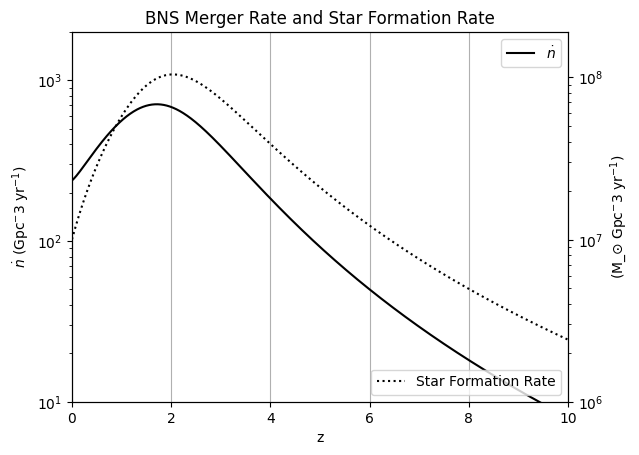

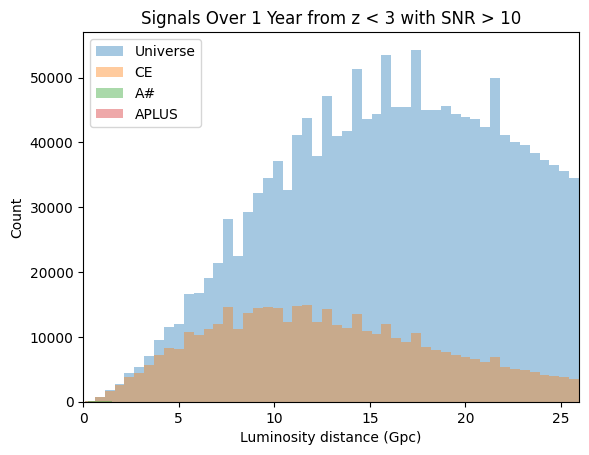

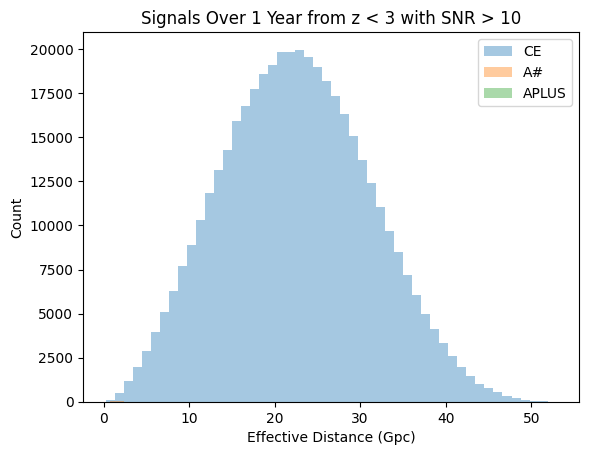

In [ ]:
population_generator(-1, #dtd slope
                      0.01, #minimum time delay
                      14, #tmax (doesn't have much effect if any )
                      3, #up to which z are we observing
                      200 / np.power(1000,3), #local rate - rate / Gpc^3 / yr , converted to 1000^3 Mpc^3 / Gpc^3
                      1, #surveytime
                      10, #minimum snr
                      1000 #z step size (makes plots smoother)
                      )
##Add local rate adjustability
#what is a good demonstration scenario for poster - reproduce/understand pervious work - KL divergence applied to different scenarious
#->connect to different chemical evolution scenarious

Statistics

In [88]:
def population_generator_data(slope, tmin, tmax, zrange, surveytime, snr, dzstep):
    redshift_basevals = np.linspace(0.001,10,dzstep)
    mergerratevalues = [mergerrate(zm, slope, tmin, tmax) for zm in redshift_basevals]



    localrate = 200 / np.power(1000,3) # rate / Gpc^3 / yr , converted to 1000^3 Mpc^3 / Gpc^3
    rate_scale = localrate / mergerrate(0.01,-1, 0.01, 14)*10**9 ##multiply by 10**9 to get it in Mpc

    
    lumdist_basevals = cosmo.luminosity_distance(redshift_basevals).value
    scale_factor_basevals =  cosmo.scale_factor(redshift_basevals)
    diff_Vc_basevals = 4.0 * np.pi * (cosmo.differential_comoving_volume(redshift_basevals).value)
    dz_base = (redshift_basevals[1]-redshift_basevals[0]) # this is our step size for our dz
    dNdz_basevals = diff_Vc_basevals * mergerratevalues *10**-9 / scale_factor_basevals
    totalmergers = round(rate_scale * sum(dNdz_basevals)*dz_base)

    nsamples = int(totalmergers)
    near = zrange
    sampletime = nsamples/(rate_scale * sum(dNdz_basevals) * dz_base)

    
    sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)
    nyearsampletotal = nsamples*surveytime/(sampletime)

    fiducial_time = surveytime # one year survey
    nearby_survey = int(nsamples * fiducial_time / sampletime_nearby)
    
    nyearsamplenear = nsamples*surveytime/(sampletime_nearby)

    nsamples = int(nyearsamplenear)
    sampletime_nearby = nsamples/(rate_scale * sum(dNdz_basevals[redshift_basevals<near]) * dz_base)

    redshifts = np.random.choice(redshift_basevals,nsamples, p=dNdz_basevals/sum(dNdz_basevals))
    redshifts_nearby = np.random.choice(redshift_basevals[redshift_basevals<near],nsamples,
                                    p=dNdz_basevals[redshift_basevals<near]/sum(dNdz_basevals[redshift_basevals<near]))

    lumdists = cosmo.luminosity_distance(redshifts).value
    lumdists_nearby = cosmo.luminosity_distance(redshifts_nearby).value


    # Sample the angles according to their pdf
    theta= np.arccos(np.random.uniform(-1,1,nsamples)) #Sky loc  # Polar
    phi =  np.pi*np.random.uniform(-1,1,nsamples)      #Sky loc  # Azimuthal
    psi =  np.pi*np.random.uniform(-1,1,nsamples)     #Polarization    # Azimuthal
    iota = np.arccos(np.random.uniform(-1,1,nsamples))  #Inclination  Polar
    # From 0903.0338: if one wants the antenna pattern referred to the detector’s own axes, then one just sets polarization ψ = 0.

    # Antenna patterns. Eq. (57) in arxiv:0903.0338
    Fplus  = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.cos(2.*psi) - np.cos(theta)*np.sin(2.*phi)*np.sin(2.*psi)
    Fcross = 0.5*(1.+np.cos(theta)**2)*np.cos(2.*phi)*np.sin(2.*psi) + np.cos(theta)*np.sin(2.*phi)*np.cos(2.*psi)
    # antenna-pattern response functions of the interferometer to the two polarizations of the wave as defined in the sky plane

    # Projection parameter. Eq. (3.31) in arxiv:gr-qc/9301003 but define littleomega=Theta/4
    # so that the optimal signal has littleomega=1
    littleomega = ( Fplus**2*(1.+np.cos(iota)**2)**2/4. +Fcross**2*np.cos(iota)**2 )**0.5
    # using notation of https://arxiv.org/pdf/1405.7016.pdf
    # projection for circular (elliptical?) polarizations

    # The resulting snr of a signal will be rho = littleomega * rho_opt
    # where rho_opt is the SNR of an optimally oriented binary at the given distance

    avg_omega = sum(littleomega)/len(littleomega)
    effective_dists = lumdists / littleomega
    effective_dists_nearby = lumdists_nearby / littleomega

    mAs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
    mBs = np.random.choice(baseNSmasses,nsamples, p=bimodal_mass_dist)
    # independent draws from the distribution
    #swap out for other mass models
    #using bimodal mass distribution parameters from Landry and Read
    mheavy = np.array([max(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])
    mlight = np.array([min(massA, massB) for (massA, massB) in np.array((mAs, mBs)).T])

    mchirps = [mchirp_from_mass1_mass2(mass1, mass2) for (mass1, mass2) in np.array((mAs, mBs)).T]
    mchirps = np.array(mchirps) 
    flow =10 # Negligible SNR below this

    fiducial_mass = 1.36 # Redshifted, detector frame
    reference_Deff = 100
    fiducial_mchirp = mchirp_from_mass1_mass2(fiducial_mass,fiducial_mass)
    deltaf=5.0
    sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=fiducial_mass, mass2=fiducial_mass,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
    
    flen = len(sptilde_fid)
    DetectorRhoList = []
    for detname in DetectorNames:
      detpsd = psd.read.from_numpy_arrays(DetectorPSDData[detname][:,0],DetectorPSDData[detname][:,1],flen,deltaf,flow)
      rhosq = sigmasq(sptilde_fid,detpsd,flow)
      DetectorRhoList.append(np.sqrt(rhosq))
    DetectorRho = dict(zip(DetectorNames, DetectorRhoList))
    
    # Fiducial mismatch tolerance:
    dict(zip(DetectorNames,[1/2/np.power(rho,2) for rho in DetectorRho.values()]))

    # Fiducial systems at increasing effective distance
    SNR_opt_of_redshift = {}
    lowind=1

    for detector in ['CE','Voyager','APLUS','ALIGO']:
      SNR_opt_of_redshift[detector] = [ DetectorRho[detector] * np.power(
      scale_factor_basevals[i] , 5./6.) * reference_Deff / lumdist_basevals[i] for i in range(len(redshift_basevals))[lowind:]]
  
    CESNRs = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)

    CESNRs_nearby = DetectorRho['CE'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    APLUSSNRs = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
    APLUSSNRs_nearby = DetectorRho['APLUS'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    ALIGOSNRs_nearby = DetectorRho['ALIGO'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    VoyagerSNRs = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists)
    VoyagerSNRs_nearby = DetectorRho['Voyager'] * np.power(
      np.array(mchirps) * (1+np.array(redshifts_nearby)) / fiducial_mchirp  , 5./6.
      ) * littleomega * reference_Deff / np.array(lumdists_nearby)

    # Mchirp scaling breaks down for CE
    # Make a quick fit
    from pycbc.conversions import mass1_from_mchirp_q
    mchList = np.linspace(
    mchirp_from_mass1_mass2(mminNS,mminNS), #lowest possible
    mchirp_from_mass1_mass2(mmaxNS,mmaxNS) * (1+redshift_basevals[-1]), #highest possible
    #1.01*max(mchirps*(1+redshifts)), # highest to encounter in full pop
    20) #Range of detector-frame (redshifted) chirp masses

    refrhoList = []
    for i, mch in enumerate(mchList):
        mref = mass1_from_mchirp_q(mch,1) #equal mass q=1
        sptilde_fid, sctilde = get_fd_waveform(approximant="IMRPhenomD_NRTidal",
                             mass1=mref, mass2=mref,
                             delta_f=deltaf, f_lower=flow, distance=reference_Deff)
        flen = len(sptilde_fid)
        detpsd = psd.read.from_numpy_arrays(DetectorPSDData['CE'][:,0],DetectorPSDData['CE'][:,1],
                                      flen,deltaf,flow)
        rhosq = sigmasq(sptilde_fid,detpsd,flow)
        refrhoList.append(np.sqrt(rhosq))

    horizondist = reference_Deff * np.array(refrhoList) / 8.0
    horizonredshift = [z_at_value(cosmo.luminosity_distance, dist *u.Mpc) for dist in horizondist]

    CESNRs_mchirp = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts))
    )* littleomega * reference_Deff / np.array(lumdists)
    CESNRs_mchirp_nearby = rho_of_mchirp_ref(
    np.array(mchirps) * (1+np.array(redshifts_nearby))
    )* littleomega * reference_Deff / np.array(lumdists_nearby)



    data = effective_dists_nearby[:nearby_survey][CESNRs_nearby[:nearby_survey]>snr]/1000
    data_to_save = data.tolist()
    print("This is a BNS CE detectable population for a DTD slope of " + str(slope) + ", a minimum time delay of " + str(tmin) + ", up to a z value of"  + str(zrange) + " for a survey time of " + str(surveytime))
    
    return data_to_save

    
    

In [60]:
import json
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

In [ ]:

#bins calculation
from astropy.stats import freedman_bin_width
freedman_bin_width(Asharp10)
bins = int((max(Asharp10) - min(Asharp10))/freedman_bin_width(Asharp10))
print(bins)
bins = np.linspace(0,4, 20)
p, _ = np.histogram(population_generator_data(-1, #dtd slope
                      0.01, #minimum time delay
                      14, #tmax (doesn't have much effect if any )
                      3, #up to which z are we observing
                      1, #surveytime
                      10, #minimum snr
                      1000 #z step size (makes plots smoother)
                      ), bins=bins, density=True)
q, _ = np.histogram(population_generator(-1, #dtd slope
                      0.01, #minimum time delay
                      14, #tmax (doesn't have much effect if any )
                      3, #up to which z are we observing
                      1, #surveytime
                      10, #minimum snr
                      1000 #z step size (makes plots smoother)
                      ), bins=bins, density=True)

# 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
# Add a small epsilon to avoid division by zero or log(0)
epsilon = 1e-10
p = p + epsilon
q = q + epsilon
p = p / np.sum(p) # Renormalize
q = q / np.sum(q)

# 4. Calculate KL Divergence
kl_pq = stats.entropy(p, q) # Base e (nats)
# kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits

print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
plt.hist(Asharp10,bins = bins, density = True)
plt.hist(Asharp20, bins = bins, density = True)
plt.title('10 Mgy vs 20Mgy Delay Time')
plt.xlabel('Effective Distance (Gpc)')
plt.ylabel('Number of Detections')

In [89]:
def kldivergence(slope1, tmin1, tmax1, slope2, tmin2, tmax2, zrange, surveytime, snr, dzstep):
    
    
    a = population_generator_data(slope1, #dtd slope
                      tmin1, #minimum time delay
                      tmax1, #tmax (doesn't have much effect if any )
                      zrange, #up to which z are we observing
                      surveytime, #surveytime
                      snr, #minimum snr
                      dzstep #z step size (makes plots smoother)
                      )
    b = population_generator_data(slope2, #dtd slope
                      tmin2, #minimum time delay
                      tmax2, #tmax (doesn't have much effect if any )
                      zrange, #up to which z are we observing
                      surveytime, #surveytime
                      snr, #minimum snr
                      dzstep #z step size (makes plots smoother)
                      )
    
    #bins calculation
    from astropy.stats import freedman_bin_width
    freedman_bin_width(a)
    bins = int((max(a) - min(a))/freedman_bin_width(a))
    print(bins)

    p, _ = np.histogram(a, bins=bins, density=True)
    q, _ = np.histogram(b, bins=bins, density=True)

    # 3. Handle Zero Probabilities (KL divergence is undefined for Q(i)=0)
    # Add a small epsilon to avoid division by zero or log(0)
    epsilon = 1e-10
    p = p + epsilon
    q = q + epsilon
    p = p / np.sum(p) # Renormalize
    q = q / np.sum(q)

    # 4. Calculate KL Divergence
    kl_pq = stats.entropy(p, q) # Base e (nats)
    # kl_pq_bits = stats.entropy(p, q, base=2) # Use base 2 for bits
    
    print(f"KL Divergence (P || Q): {kl_pq:.4f} nats")
    plt.figure()
    plt.hist(a,bins = bins, density = True,)
    plt.hist(b, bins = bins, density = True, color = 'orange', alpha = 0.5)
    plt.title('Populations')
    plt.xlabel('Effective Distance (Gpc)')
    plt.ylabel('Number of Detections')
    return kl_pq

This is a BNS CE detectable population for a DTD slope of -1, a minimum time delay of 0.01, up to a z value of3 for a survey time of 1
This is a BNS CE detectable population for a DTD slope of -1.0, a minimum time delay of 0.01, up to a z value of3 for a survey time of 1
163
KL Divergence (P || Q): 0.0006 nats


np.float64(0.0005893385862451427)

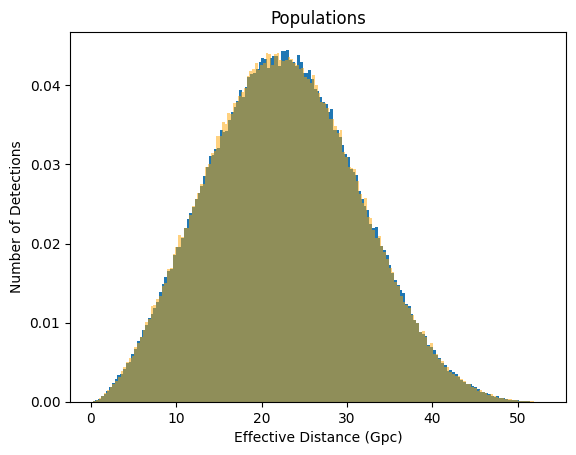

In [93]:
kldivergence(-1, 0.01, 14, -1., 0.01, 14, 3, 1, 10, 1000)